In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Load data
train_df = pd.read_csv('/Users/joshbuck/ClinicalMeetingRecorder/ClinicalMeetingRecorder/data/raw/MTS-Dialog-TrainingSet.csv')
val_df = pd.read_csv('/Users/joshbuck/ClinicalMeetingRecorder/ClinicalMeetingRecorder/data/raw/MTS-Dialog-ValidationSet.csv')

#section grouping from EDA
section_mapping = {
    'GENHX': 'History',
    'FAM/SOCHX': 'History',
    'PASTMEDICALHX': 'History',
    'PASTSURGICAL': 'History',
    'OTHER_HISTORY': 'History',
    'GYNHX': 'History',
    'CC': 'Chief Complaint',
    'ROS': 'Exam/Review',
    'EXAM': 'Exam/Review',
    'ALLERGY': 'Medications/Allergies',
    'MEDICATIONS': 'Medications/Allergies',
    'IMMUNIZATIONS': 'Medications/Allergies',
    'ASSESSMENT': 'Assessment/Diagnosis',
    'DIAGNOSIS': 'Assessment/Diagnosis',
    'PLAN': 'Plan/Disposition',
    'DISPOSITION': 'Plan/Disposition',
    'EDCOURSE': 'Plan/Disposition',
    'PROCEDURES': 'Plan/Disposition',
    'IMAGING': 'Plan/Disposition',
    'LABS': 'Plan/Disposition',
}

train_df['section_group'] = train_df['section_header'].map(section_mapping)
val_df['section_group'] = val_df['section_header'].map(section_mapping)

print(f"Training: {len(train_df)} samples")
print(f"Validation: {len(val_df)} samples")
print(f"\nTarget distribution:")
print(train_df['section_group'].value_counts())

Training: 1201 samples
Validation: 100 samples

Target distribution:
section_group
History                  821
Medications/Allergies    122
Exam/Review               83
Chief Complaint           77
Assessment/Diagnosis      53
Plan/Disposition          45
Name: count, dtype: int64


In [3]:
#Build TF-IDF features from dialogue
tfidf = TfidfVectorizer(
    max_features=500,       #keep top 500 terms for now
    stop_words='english',   #remove the common words
    ngram_range=(1, 2),     #unigrams and bigrams
    min_df=2,               #term must appear in at least 2 documents
    max_df=0.95             #ignore terms in >95% of docs for now
)

#fit on training data and transform both
X_train_tfidf = tfidf.fit_transform(train_df['dialogue'])
X_val_tfidf = tfidf.transform(val_df['dialogue'])

y_train = train_df['section_group']
y_val = val_df['section_group']

print(f"TF-IDF feature matrix shape: {X_train_tfidf.shape}")
print(f"(Thats {X_train_tfidf.shape[0]} samples x {X_train_tfidf.shape[1]} features)")
print(f"\nTop 20 features by name:")
print(tfidf.get_feature_names_out()[:20])

TF-IDF feature matrix shape: (1201, 500)
(Thats 1201 samples x 500 features)

Top 20 features by name:
['able' 'absolutely' 'activities' 'actually' 'afternoon'
 'afternoon doctor' 'age' 'ago' 'ago doctor' 'ah' 'alcohol'
 'alcohol patient' 'allergic' 'allergies' 'allergies patient' 'alright'
 'antibiotics' 'anymore' 'area' 'arm']


In [4]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

#train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

#predict on validation set
y_pred = nb_model.predict(X_val_tfidf)

#results
print(f"Accuracy: {accuracy_score(y_val, y_pred):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 0.610

Classification Report:
                       precision    recall  f1-score   support

 Assessment/Diagnosis       0.00      0.00      0.00         5
      Chief Complaint       0.00      0.00      0.00         4
          Exam/Review       1.00      0.25      0.40        12
              History       0.59      1.00      0.74        56
Medications/Allergies       1.00      0.17      0.29        12
     Plan/Disposition       0.00      0.00      0.00        11

             accuracy                           0.61       100
            macro avg       0.43      0.24      0.24       100
         weighted avg       0.57      0.61      0.50       100



/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

In [5]:
from sklearn.linear_model import LogisticRegression

#naive Bayes with class balancing
nb_balanced = MultinomialNB(alpha=0.1)

#logistic Regression with class weight balancing
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  #this automatically upweights minority classes
    random_state=42
)

#train both
nb_balanced.fit(X_train_tfidf, y_train)
lr_model.fit(X_train_tfidf, y_train)

#compare
print("=== Naive Bayes (alpha=0.1) ===")
y_pred_nb = nb_balanced.predict(X_val_tfidf)
print(f"Accuracy: {accuracy_score(y_val, y_pred_nb):.3f}")
print(classification_report(y_val, y_pred_nb, zero_division=0))

print("\n=== Logistic Regression (balanced) ===")
y_pred_lr = lr_model.predict(X_val_tfidf)
print(f"Accuracy: {accuracy_score(y_val, y_pred_lr):.3f}")
print(classification_report(y_val, y_pred_lr, zero_division=0))

=== Naive Bayes (alpha=0.1) ===
Accuracy: 0.690
                       precision    recall  f1-score   support

 Assessment/Diagnosis       0.00      0.00      0.00         5
      Chief Complaint       0.67      0.50      0.57         4
          Exam/Review       1.00      0.58      0.74        12
              History       0.65      0.98      0.79        56
Medications/Allergies       1.00      0.33      0.50        12
     Plan/Disposition       1.00      0.09      0.17        11

             accuracy                           0.69       100
            macro avg       0.72      0.41      0.46       100
         weighted avg       0.74      0.69      0.63       100


=== Logistic Regression (balanced) ===
Accuracy: 0.710
                       precision    recall  f1-score   support

 Assessment/Diagnosis       0.22      0.40      0.29         5
      Chief Complaint       0.09      0.25      0.13         4
          Exam/Review       0.90      0.75      0.82        12
          

In [6]:
from scipy.sparse import hstack
import re

def extract_dialogue_features(df):
    """Extract numerical features from dialogues."""
    features = pd.DataFrame()
    features['word_count'] = df['dialogue'].str.split().str.len()
    features['turn_count'] = df['dialogue'].str.count(r'Doctor:|Patient:|\[doctor\]|\[patient\]')

    #doc vs pt word counts
    features['doctor_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Doctor|doctor).*?(?=Patient|patient|$)', x, re.DOTALL)).split())
    )
    features['patient_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Patient|patient).*?(?=Doctor|doctor|$)', x, re.DOTALL)).split())
    )
    features['avg_turn_length'] = features['word_count'] / features['turn_count'].clip(lower=1)

    return features

#build combined features: TF-IDF + dialogue features
train_extra = extract_dialogue_features(train_df)
val_extra = extract_dialogue_features(val_df)

X_train_combined = hstack([X_train_tfidf, train_extra.values])
X_val_combined = hstack([X_val_tfidf, val_extra.values])

print(f"Combined feature shape: {X_train_combined.shape}")
print(f"(500 TF-IDF + {train_extra.shape[1]} dialogue features)")

#retrain Logistic Regression with combined features
lr_combined = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_combined.fit(X_train_combined, y_train)

y_pred_combined = lr_combined.predict(X_val_combined)
print(f"\nAccuracy: {accuracy_score(y_val, y_pred_combined):.3f}")
print(classification_report(y_val, y_pred_combined, zero_division=0))

Combined feature shape: (1201, 505)
(500 TF-IDF + 5 dialogue features)

Accuracy: 0.710
                       precision    recall  f1-score   support

 Assessment/Diagnosis       0.20      0.40      0.27         5
      Chief Complaint       0.14      0.50      0.22         4
          Exam/Review       0.85      0.92      0.88        12
              History       0.93      0.77      0.84        56
Medications/Allergies       0.83      0.42      0.56        12
     Plan/Disposition       0.73      0.73      0.73        11

             accuracy                           0.71       100
            macro avg       0.61      0.62      0.58       100
         weighted avg       0.82      0.71      0.75       100



/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MaxAbsScaler

#scale features
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_val_scaled = scaler.transform(X_val_combined)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'SVM (Linear)': SVC(kernel='linear', class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, zero_division=0, output_dict=True)
    results[name] = {
        'accuracy': acc,
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score'],
    }
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.3f} | Macro F1: {report['macro avg']['f1-score']:.3f} | Weighted F1: {report['weighted avg']['f1-score']:.3f}\n")

#summary comparison
print("\n=== MODEL COMPARISON ===")
comparison = pd.DataFrame(results).T.sort_values('macro_f1', ascending=False)
print(comparison.round(3))

=== Logistic Regression ===
Accuracy: 0.730 | Macro F1: 0.593 | Weighted F1: 0.768

=== SVM (RBF) ===
Accuracy: 0.750 | Macro F1: 0.568 | Weighted F1: 0.740

=== SVM (Linear) ===
Accuracy: 0.720 | Macro F1: 0.541 | Weighted F1: 0.741

=== Random Forest ===
Accuracy: 0.700 | Macro F1: 0.469 | Weighted F1: 0.637


=== MODEL COMPARISON ===
                     accuracy  macro_f1  weighted_f1
Logistic Regression      0.73     0.593        0.768
SVM (RBF)                0.75     0.568        0.740
SVM (Linear)             0.72     0.541        0.741
Random Forest            0.70     0.469        0.637


In [8]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

#encode labels for XGBoost
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

#all models
cv_models = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'SVM (Linear)': SVC(kernel='linear', class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='mlogloss'),
}

print("5-Fold Cross-Validation (Macro F1)\n")
cv_results = {}
for name, model in cv_models.items():
    #since NB needs non-negative data, use unscaled TF-IDF only
    if name == 'Naive Bayes':
        scores = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring='f1_macro')
    elif name == 'XGBoost':
        scores = cross_val_score(model, X_train_scaled, y_train_encoded, cv=5, scoring='f1_macro')
    else:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1_macro')

    cv_results[name] = scores
    print(f"{name:25s}  F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")

print("\n(+/- shows standard deviation across folds)")

5-Fold Cross-Validation (Macro F1)

Naive Bayes                F1 = 0.439 (+/- 0.027)
Logistic Regression        F1 = 0.581 (+/- 0.030)
SVM (RBF)                  F1 = 0.535 (+/- 0.065)
SVM (Linear)               F1 = 0.564 (+/- 0.045)
Random Forest              F1 = 0.412 (+/- 0.040)
XGBoost                    F1 = 0.512 (+/- 0.096)

(+/- shows standard deviation across folds)


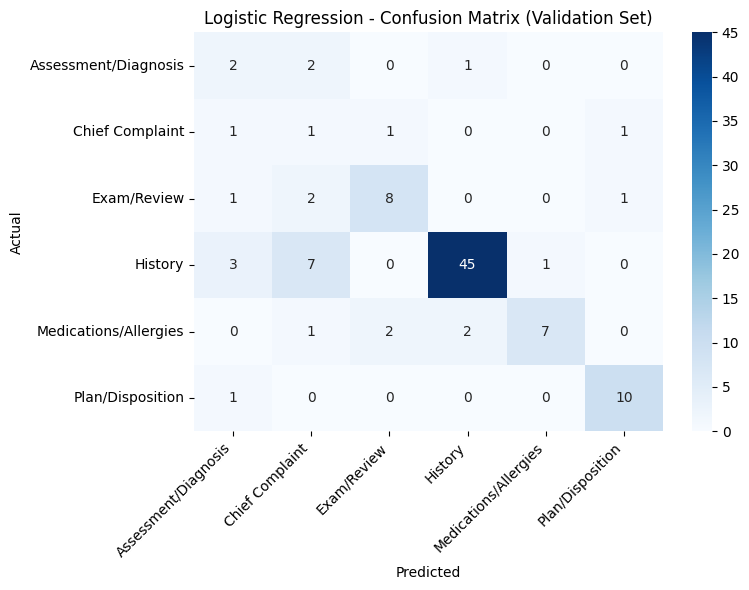

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#retrain LR on full training set, predict on validation
lr_best = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
lr_best.fit(X_train_scaled, y_train)
y_pred_best = lr_best.predict(X_val_scaled)

# Confusion matrix
labels = sorted(y_train.unique())
cm = confusion_matrix(y_val, y_pred_best, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression - Confusion Matrix (Validation Set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

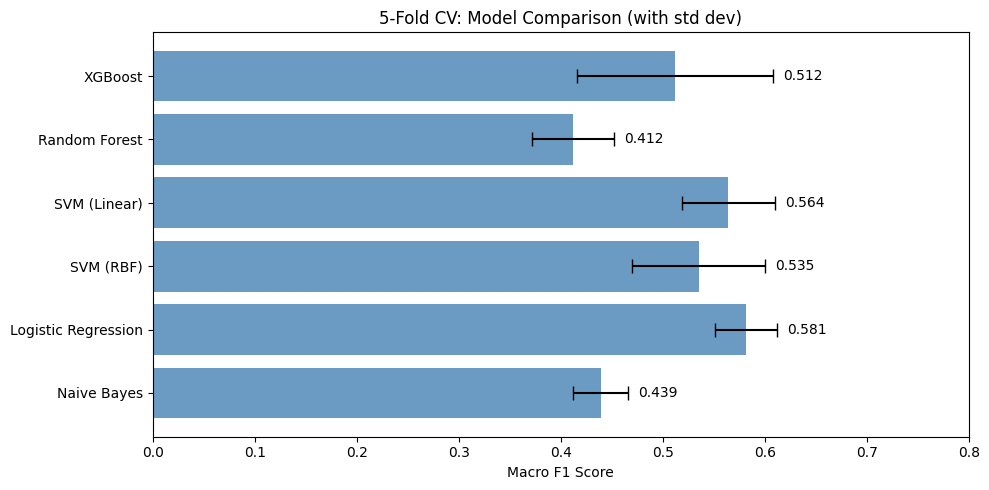

In [10]:
#visualize cross-validation results
fig, ax = plt.subplots(figsize=(10, 5))

names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds = [cv_results[n].std() for n in names]

bars = ax.barh(names, means, xerr=stds, capsize=5, color='steelblue', alpha=0.8)
ax.set_xlabel('Macro F1 Score')
ax.set_title('5-Fold CV: Model Comparison (with std dev)')
ax.set_xlim(0, 0.8)

#value labels
for bar, mean, std in zip(bars, means, stds):
    ax.text(mean + std + 0.01, bar.get_y() + bar.get_height()/2,
            f'{mean:.3f}', va='center')

plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import GridSearchCV

#define parameter grids for top 3 models
param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(class_weight='balanced', random_state=42, max_iter=2000),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['lbfgs', 'liblinear'],
        }
    },
    'SVM (Linear)': {
        'model': SVC(kernel='linear', class_weight='balanced', random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='mlogloss'),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.3],
        }
    },
}

tuned_results = {}
for name, config in param_grids.items():
    if name == 'XGBoost':
        grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='f1_macro', n_jobs=-1)
        grid.fit(X_train_scaled, y_train_encoded)
    else:
        grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='f1_macro', n_jobs=-1)
        grid.fit(X_train_scaled, y_train)

    tuned_results[name] = grid
    print(f"{name}:")
    print(f"  Best params: {grid.best_params_}")
    print(f"  Best Macro F1: {grid.best_score_:.3f}\n")

print("=== TUNED MODEL COMPARISON ===")
for name, grid in tuned_results.items():
    print(f"{name:25s}  F1 = {grid.best_score_:.3f}")

Logistic Regression:
  Best params: {'C': 0.1, 'solver': 'liblinear'}
  Best Macro F1: 0.591

SVM (Linear):
  Best params: {'C': 0.1}
  Best Macro F1: 0.580

XGBoost:
  Best params: {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 100}
  Best Macro F1: 0.535

=== TUNED MODEL COMPARISON ===
Logistic Regression        F1 = 0.591
SVM (Linear)               F1 = 0.580
XGBoost                    F1 = 0.535


PCA explained variance: [0.02432374 0.01615225]
Total variance explained by 2 components: 0.040


/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normaliz

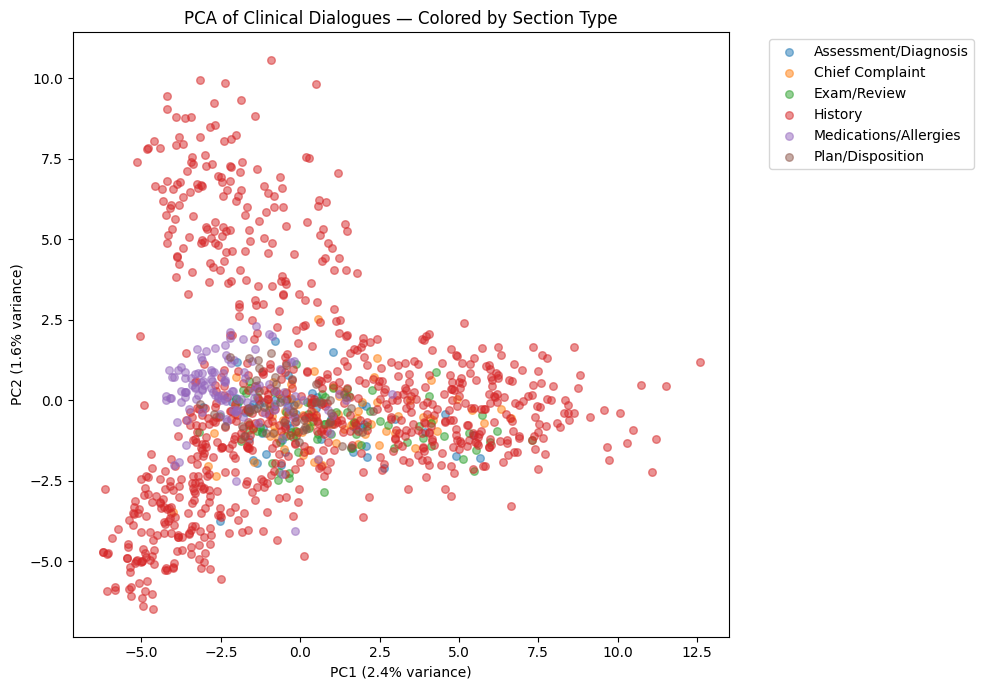

In [12]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#PCA on TF-IDF features - reduce 505 dimensions to 2 for visualization
scaler_pca = StandardScaler()
X_dense = X_train_combined.toarray()
X_std = scaler_pca.fit_transform(X_dense)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

print(f"PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {sum(pca.explained_variance_ratio_):.3f}")

#plot PCA colored by section group
fig, ax = plt.subplots(figsize=(10, 7))
for label in sorted(y_train.unique()):
    mask = y_train == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label, alpha=0.5, s=30)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA of Clinical Dialogues — Colored by Section Type')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_po

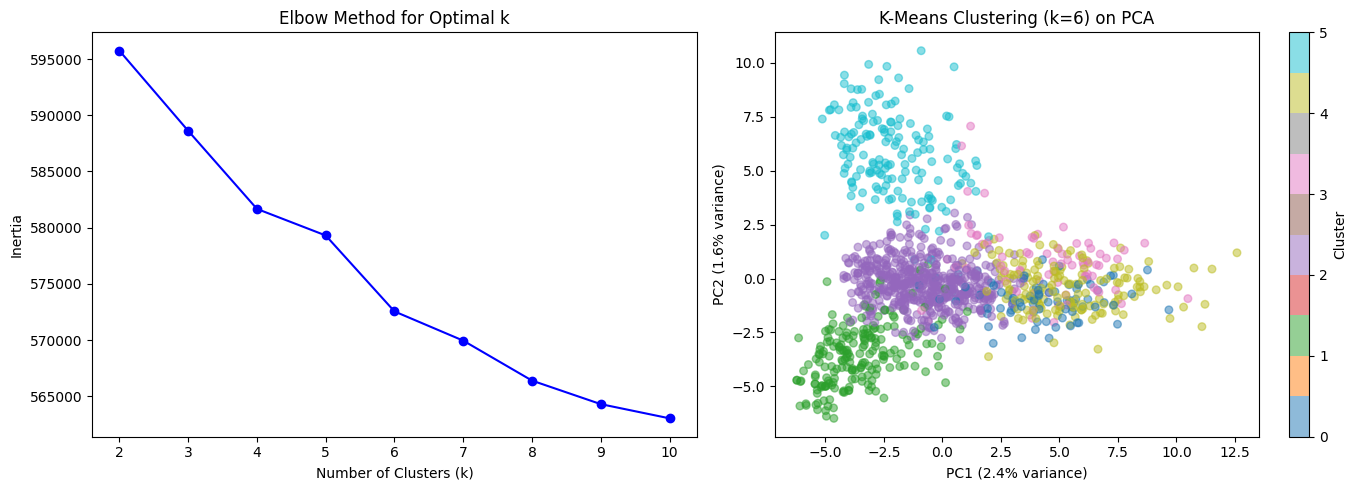

Cluster vs Section Group crosstab:
col_0                   0    1    2   3    4    5   All
section_group                                          
Assessment/Diagnosis    4    1   44   0    4    0    53
Chief Complaint         9    2   56   0   10    0    77
Exam/Review            27    0   55   0    1    0    83
History                40  196  213  75  139  158   821
Medications/Allergies   0    1  120   0    1    0   122
Plan/Disposition        1    0   44   0    0    0    45
All                    81  200  532  75  155  158  1201


In [13]:
#K-Means clustering tofind natural groupings in the data
#try different k values and measure inertia aka the 'elbow method'
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_std)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#left: Elbow plot
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')

#right: K-Means with k=6 (matching our 6 section groups) on PCA
km6 = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = km6.fit_predict(X_std)

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels,
                          cmap='tab10', alpha=0.5, s=30)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('K-Means Clustering (k=6) on PCA')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

print("Cluster vs Section Group crosstab:")
print(pd.crosstab(y_train, cluster_labels, margins=True))